# Exploring standardizations for channel features.

### Libraries.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytometry as pm
import scanpy as sc
from scipy.stats import energy_distance
import seaborn as sns
from sklearn.neighbors import KernelDensity



### Constants.

In [2]:
# working locally?
IS_RUN_LOCALLY = True

# paths
if IS_RUN_LOCALLY:
    H5AD_PATH = "/Users/lorenzo.consoli/Work/data/collab-goettgens/ds_HID01_logicle_100k_UMAP_ann.h5ad"
else:
    H5AD_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/gdrive/ds_HID01_logicle_100k_UMAP_ann.h5ad"


### Utility functions.

In [3]:
def plot_covariance_or_correlation(X, Y=None, columns_X=None, columns_Y=None, 
                                   figsize=(10, 8), correlation=False):

    # compute covariance or correlation
    if Y is None:
        data = X
        if correlation:
            mat = np.corrcoef(data, rowvar=False)
        else:
            mat = np.cov(data, rowvar=False)
    else:
        if correlation:
            # concatenate to compute full correlation, then extract cross-correlation
            combined = np.hstack([X, Y])
            full_corr = np.corrcoef(combined, rowvar=False)
            mat = full_corr[:X.shape[1], X.shape[1]:]
        else:
            mat = np.cov(X, Y, rowvar=False)[:X.shape[1], X.shape[1]:]

    # default labels
    if columns_X is None:
        columns_X = [f"X{i}" for i in range(X.shape[1])]
    if Y is None:
        columns_Y = columns_X
    elif columns_Y is None:
        columns_Y = [f"Y{i}" for i in range(Y.shape[1])]

    # plot
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        mat,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        cbar_kws={"shrink": 0.8, "label": "Correlation" if correlation else "Covariance"},
        ax=ax
    )

    # set ticks and labels
    ax.set_xticks(range(len(columns_Y)))
    ax.set_yticks(range(len(columns_X)))
    ax.set_xticklabels(columns_Y, rotation=45, ha="right")
    ax.set_yticklabels(columns_X, rotation=0)

    ax.set_title("Correlation Matrix" if correlation else "Covariance Matrix", fontsize=14)
    ax.set_xlabel("Y Features")
    ax.set_ylabel("X Features")

    plt.tight_layout()
    plt.show()


### Reading data.

In [4]:
adata = sc.read_h5ad(H5AD_PATH)
adata

AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'positives', 'raw'
    

### Random shit

### KDE Plot per cell type.

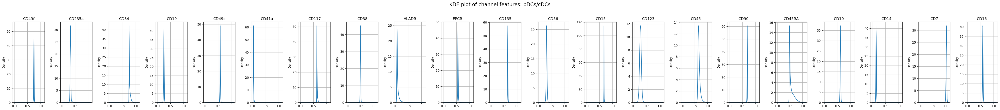

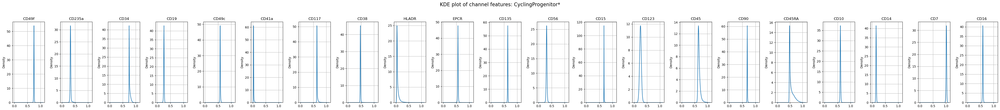

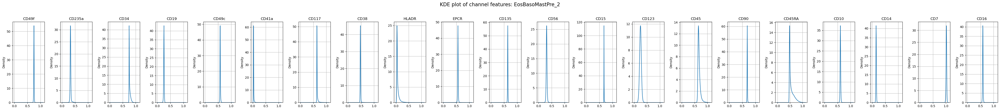

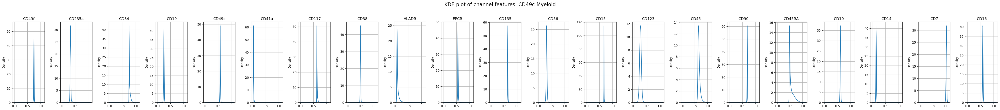

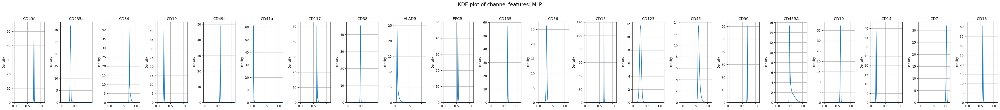

...

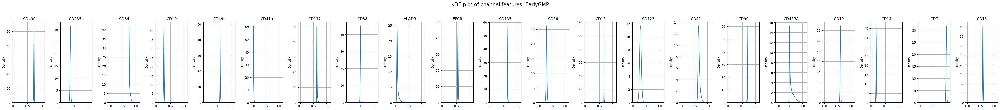

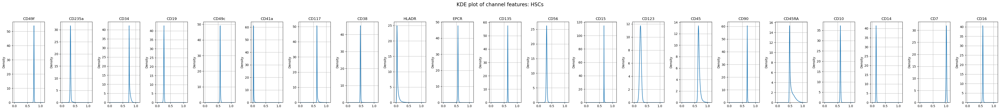

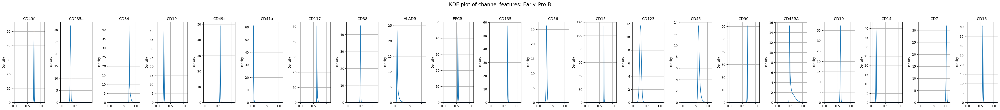

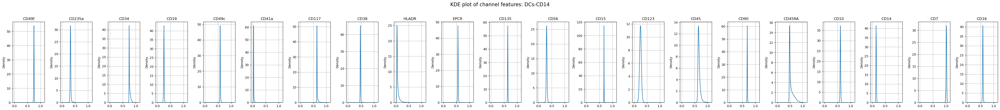

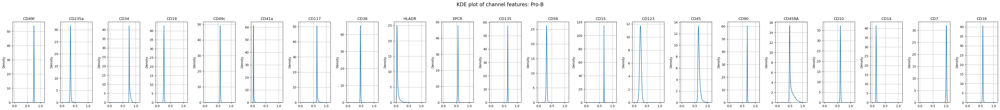

In [15]:
from scipy.special import expit
K = 2
X = np.log1p(K*(adata.X - adata.X.min(0)) / (adata.X.max(0) - adata.X.min(0)))
kde_plot_per_cell_type = True
if kde_plot_per_cell_type:
    # make sure adata.obs['cel\l_type'] exists
    cell_types = adata.obs['cell_type'].unique()
    n_channels = adata.shape[1]

    for cell_type in cell_types:
        # select cells of this type
        idx_cells = adata.obs['cell_type'] == cell_type
        X_subset = X[idx_cells, :]  # subset of data

        # create subplots (1 row, n_channels columns)
        fig, ax = plt.subplots(1, n_channels, figsize=(45, 5))
        fig.suptitle(f"KDE plot of channel features: {cell_type}", fontsize=16)

        # loop over channels
        for i in range(n_channels):
            sns.kdeplot(X[:, i], ax=ax[i])
            ax[i].grid(True)
            ax[i].set_title(adata.var_names[i])

        plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for suptitle
        plt.show()

## MinMax standardization oer -1, 1.

### KDE Plot per cell type.

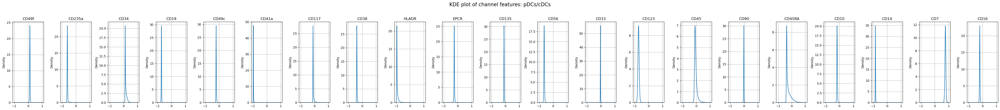

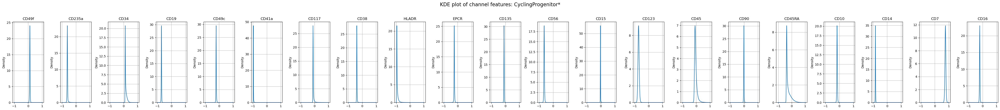

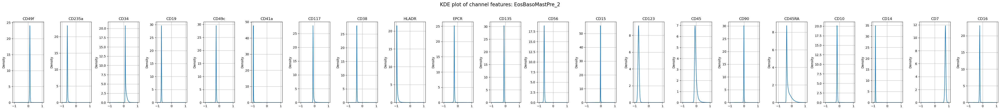

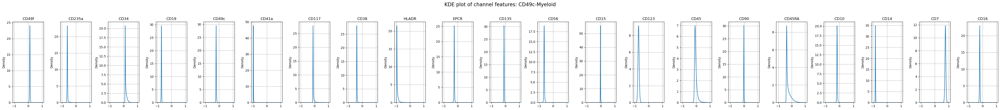

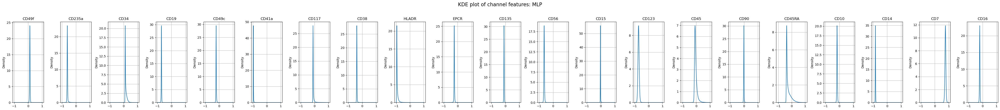

...

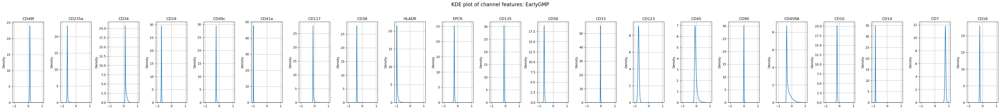

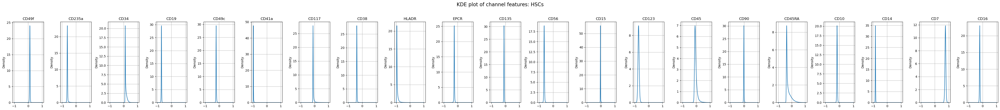

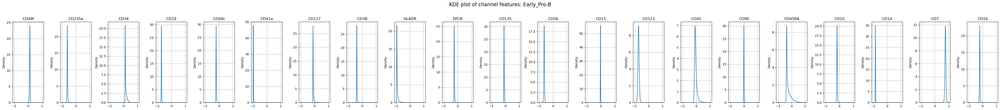

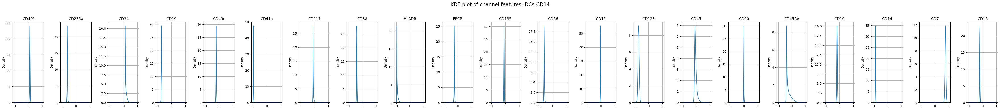

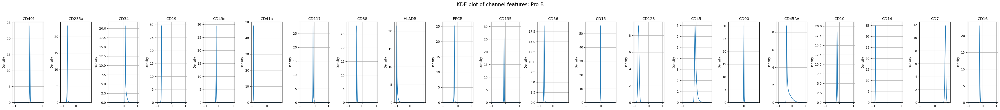

In [9]:
X = 2*(adata.X - adata.X.min(0)) / (adata.X.max(0) - adata.X.min(0)) - 1
kde_plot_per_cell_type = True
if kde_plot_per_cell_type:
    # make sure adata.obs['cel\l_type'] exists
    cell_types = adata.obs['cell_type'].unique()
    n_channels = adata.shape[1]

    for cell_type in cell_types:
        # select cells of this type
        idx_cells = adata.obs['cell_type'] == cell_type
        X_subset = X[idx_cells, :]  # subset of data

        # create subplots (1 row, n_channels columns)
        fig, ax = plt.subplots(1, n_channels, figsize=(45, 5))
        fig.suptitle(f"KDE plot of channel features: {cell_type}", fontsize=16)

        # loop over channels
        for i in range(n_channels):
            sns.kdeplot(X[:, i], ax=ax[i])
            ax[i].grid(True)
            ax[i].set_title(adata.var_names[i])

        plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for suptitle
        plt.show()

## Mean0 std 1.

### KDE Plot per cell type.

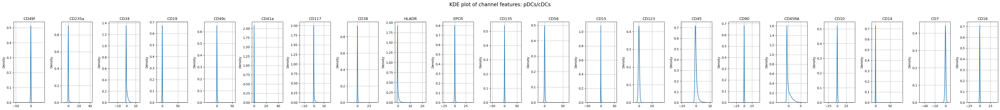

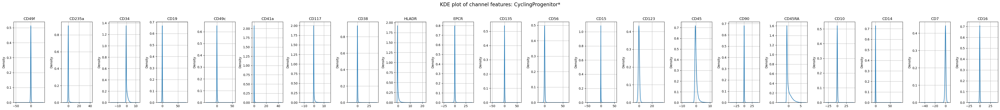

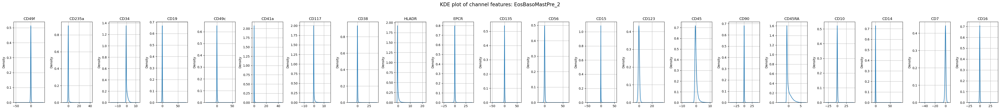

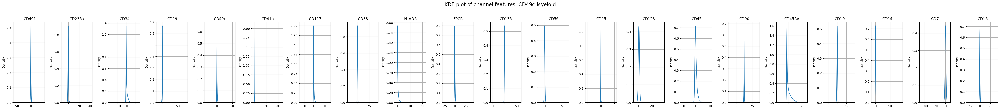

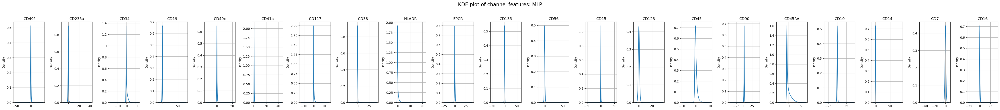

...

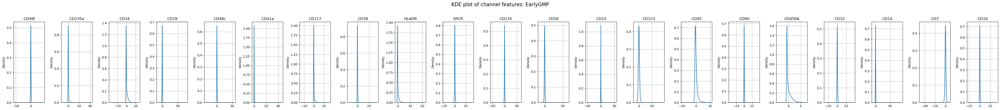

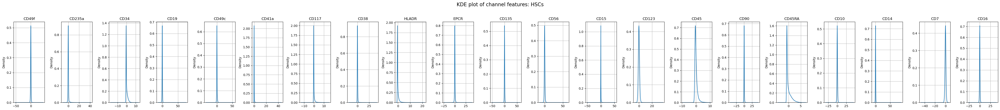

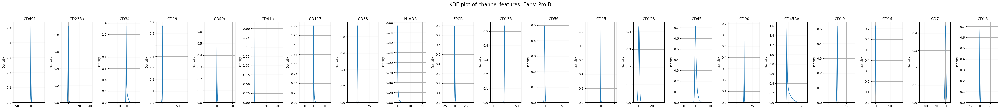

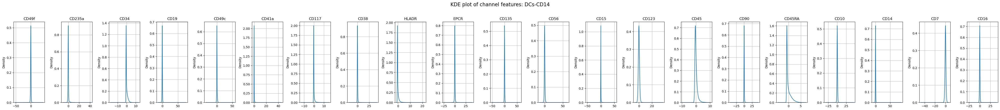

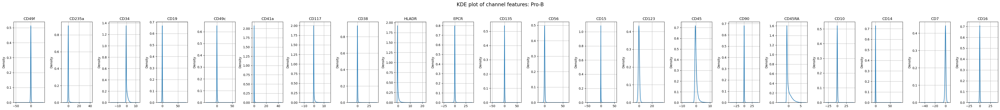

In [10]:
X = (adata.X - adata.X.mean(0)) / adata.X.std(0)
kde_plot_per_cell_type = True
if kde_plot_per_cell_type:
    # make sure adata.obs['cel\l_type'] exists
    cell_types = adata.obs['cell_type'].unique()
    n_channels = adata.shape[1]

    for cell_type in cell_types:
        # select cells of this type
        idx_cells = adata.obs['cell_type'] == cell_type
        X_subset = X[idx_cells, :]  # subset of data

        # create subplots (1 row, n_channels columns)
        fig, ax = plt.subplots(1, n_channels, figsize=(45, 5))
        fig.suptitle(f"KDE plot of channel features: {cell_type}", fontsize=16)

        # loop over channels
        for i in range(n_channels):
            sns.kdeplot(X[:, i], ax=ax[i])
            ax[i].grid(True)
            ax[i].set_title(adata.var_names[i])

        plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space for suptitle
        plt.show()